In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
# load clean data and pick features
df = pd.read_csv("../data/processed/clean_tracks.csv")
features = ["danceability", "energy", "loudness", "speechiness",
            "acousticness", "instrumentalness", "liveness",
            "valence", "tempo"]


In [3]:
X = StandardScaler().fit_transform(df[features])


In [5]:
ks = range(2, 11)
inertias, sil_scores = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels, sample_size=10000, random_state=42))



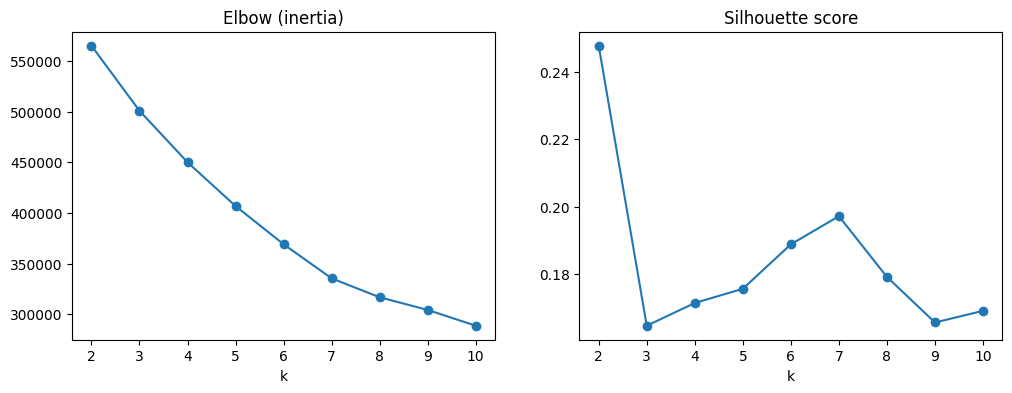

In [6]:
# 4. plot both
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ks, inertias, marker="o"); ax[0].set_title("Elbow (inertia)")
ax[1].plot(ks, sil_scores, marker="o"); ax[1].set_title("Silhouette score")
for a in ax: a.set_xlabel("k")
plt.show()

In [7]:
km = KMeans(n_clusters=7, random_state=42, n_init=10)
df["cluster"] = km.fit_predict(X)

print(df.groupby("cluster")[features].mean())

         danceability    energy   loudness  speechiness  acousticness  \
cluster                                                                 
0            0.588933  0.738439  -8.480036     0.071356      0.115385   
1            0.570503  0.682902 -11.124186     0.851317      0.750745   
2            0.704512  0.715395  -6.629080     0.097632      0.225764   
3            0.516888  0.752317  -7.142226     0.088018      0.295051   
4            0.470360  0.822630  -5.310971     0.086718      0.073101   
5            0.528641  0.378403 -10.625125     0.054233      0.681137   
6            0.351862  0.170914 -21.250616     0.052133      0.870088   

         instrumentalness  liveness   valence       tempo  
cluster                                                    
0                0.795850  0.168124  0.347349  126.987367  
1                0.006711  0.674816  0.434107  100.239707  
2                0.021734  0.165327  0.699674  118.413311  
3                0.078731  0.750173  0.498

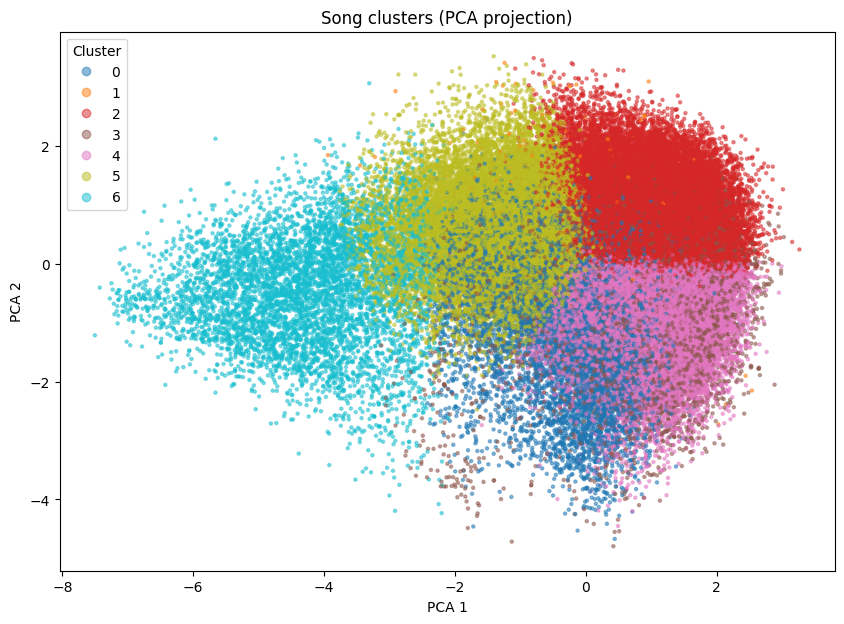

Variance explained: [0.31825442 0.15970561]


In [12]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
# 2. add to dataframe
df["pca1"] = coords[:, 0]
df["pca2"] = coords[:, 1]

# 3. plot, colored by cluster
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df["pca1"], df["pca2"], c=df["cluster"], cmap="tab10", s=5, alpha=0.5)
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Song clusters (PCA projection)")
plt.show()

print("Variance explained:", pca.explained_variance_ratio_)